In [6]:
import json
import csv

# Load your JSON data from file
with open('./data/adastat-pools.json', 'r') as f:
    data = json.load(f)
data=data["rows"]
# If it's a list of objects, do nothing
# If it's just one object (as in your example), wrap it in a list
if isinstance(data, dict):
    data = [data]

# Flatten 'ros' into separate keys like 'ros_0', 'ros_1', etc.
for row in data:
    ros = row.pop("ros", {})
    for key, value in ros.items():
        row[f"ros_{key}"] = value

# Define output CSV columns (optional: let CSV module auto-detect from keys)
fieldnames = sorted(set().union(*(d.keys() for d in data)))

# Write to CSV
with open('./data/adastat-pools-rows.csv', 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(data)

print("CSV created as 'adastat-pools-rows.csv'")


CSV created as 'adastat-pools-rows.csv'


In [47]:
import pandas as pd

# Load CSV into a DataFrame
df = pd.read_csv('./data/adastat-pools-rows.csv')

# Show the first few rows
print(df.columns)


Index(['active_stake', 'bech32', 'block', 'block_epoch', 'cluster_name',
       'cluster_order', 'delegator', 'fixed_cost', 'hash', 'impersonator',
       'itn', 'live_stake', 'margin', 'mithril', 'name', 'owner_stake',
       'pledge', 'pool_fee', 'reg_time', 'retiring_epoch', 'reward_amount',
       'ros_0', 'ros_1', 'ros_12', 'ros_18', 'ros_2', 'ros_3', 'ros_36',
       'ros_6', 'ros_73', 'ticker', 'total_block', 'valid_meta'],
      dtype='object')


In [48]:
# Convert numeric columns properly
df = df.apply(pd.to_numeric, errors='coerce')

# Drop non-numeric columns (like strings or NaNs)
df_num = df.select_dtypes(include='number')

# Compute correlations with 'active_stake'
correlations = df_num.corr()['active_stake'].drop('active_stake').sort_values(ascending=False)

print("Top correlated columns with active_stake:")
print(correlations.head(100))  # Show top 10

Top correlated columns with active_stake:
live_stake        0.998736
block             0.951694
retiring_epoch    0.786777
total_block       0.766329
reward_amount     0.641841
ros_36            0.580893
ros_73            0.572210
ros_18            0.571479
ros_12            0.569431
ros_6             0.549020
block_epoch       0.502529
ros_3             0.497221
ros_2             0.415085
owner_stake       0.357460
delegator         0.353817
ros_0             0.292586
pool_fee          0.285766
pledge            0.162115
margin            0.080348
reg_time          0.077887
fixed_cost        0.007866
cluster_order    -0.032209
ticker           -0.225899
name             -1.000000
bech32                 NaN
cluster_name           NaN
hash                   NaN
ros_1                  NaN
Name: active_stake, dtype: float64


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def drop_highly_correlated_features(df, target_col, threshold=0.9):
    df_numeric = df.select_dtypes(include='number').dropna()

    corr_matrix = df_numeric.corr().abs()

    # Upper triangle only
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = set()
    to_keep = {}

    for col1 in upper.columns:
        for col2 in upper.index:
            if pd.isna(upper.loc[col2, col1]):
                continue
            if upper.loc[col2, col1] > threshold:
                # Compare correlations to the target
                corr1 = abs(df_numeric[col1].corr(df_numeric[target_col]))
                corr2 = abs(df_numeric[col2].corr(df_numeric[target_col]))

                if corr1 >= corr2:
                    to_drop.add(col2)
                    to_keep[col1] = col2
                else:
                    to_drop.add(col1)
                    to_keep[col2] = col1

    print("Dropping columns due to high correlation:")
    for keep, drop in to_keep.items():
        print(f"🟢 Keeping: {keep} | 🔴 Dropping: {drop}")

    # df_reduced = df.drop(columns=to_drop, errors='ignore')
    # return df_reduced

def plot_two_axis(df, x_col, y_col, title=None, xlabel=None, ylabel=None):
    """
    Plot a graph with x-axis and y-axis from specified DataFrame columns.

    Parameters:
    - df: pandas DataFrame
    - x_col: str, column name for x-axis
    - y_col: str, column name for y-axis
    - title: str, optional, plot title
    - xlabel: str, optional, x-axis label
    - ylabel: str, optional, y-axis label
    """
    plt.figure(figsize=(8,5))
    plt.scatter(df[x_col], df[y_col])
    if title:
        plt.title(title)
    plt.xlabel(xlabel if xlabel else x_col)
    plt.ylabel(ylabel if ylabel else y_col)
    plt.grid(True)
    plt.tight_layout()
    plt.show()



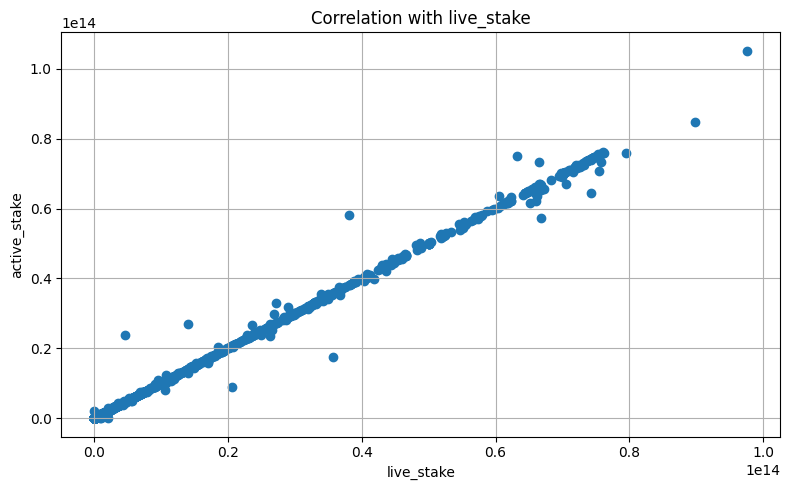

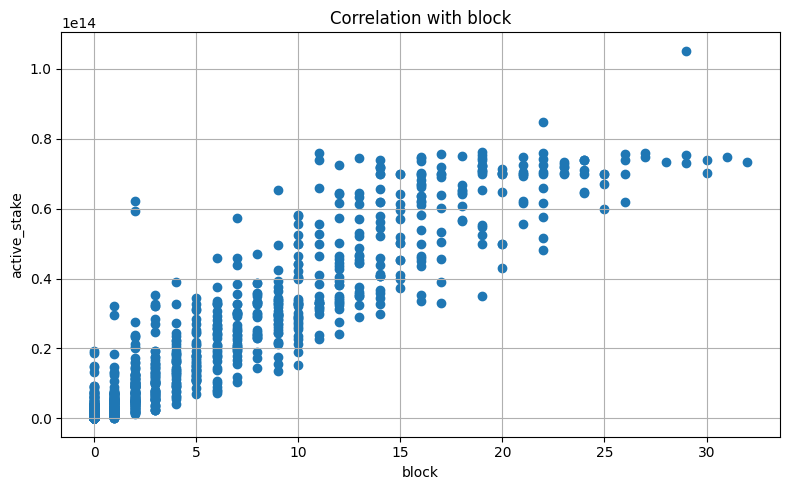

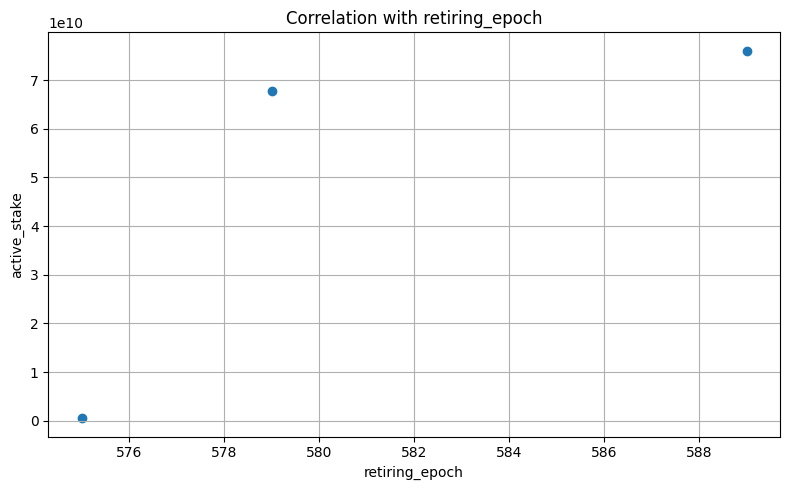

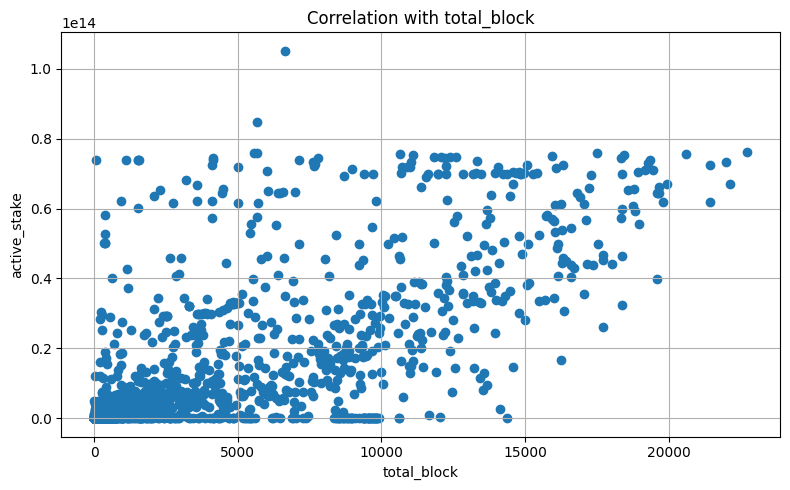

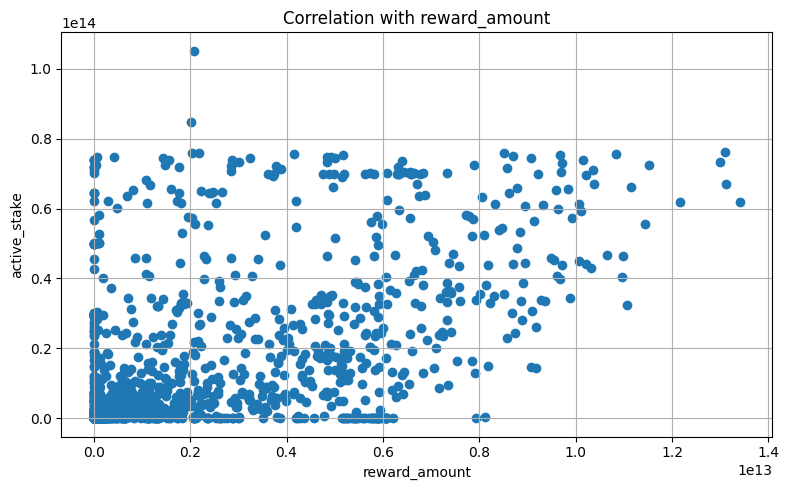

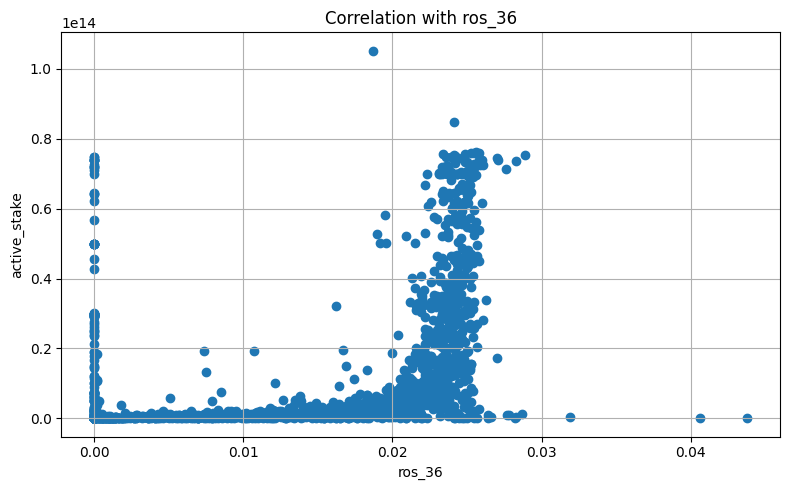

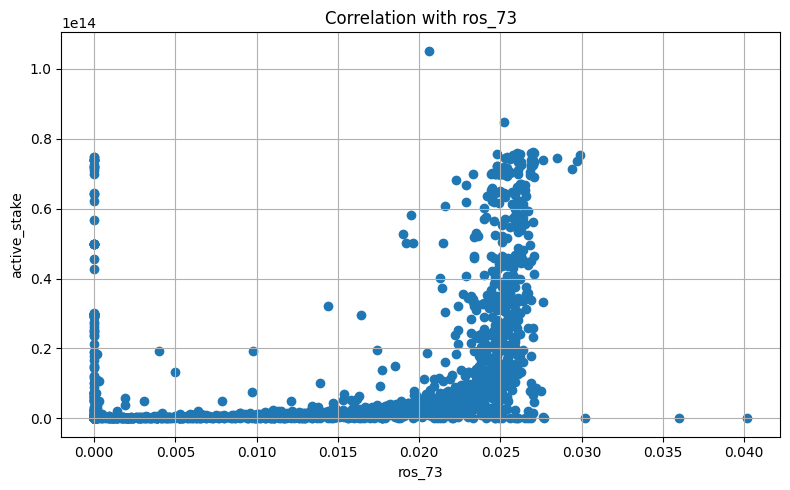

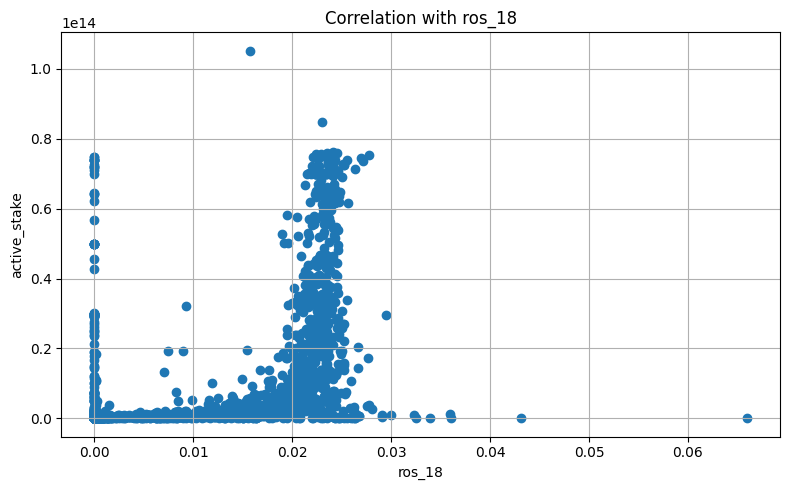

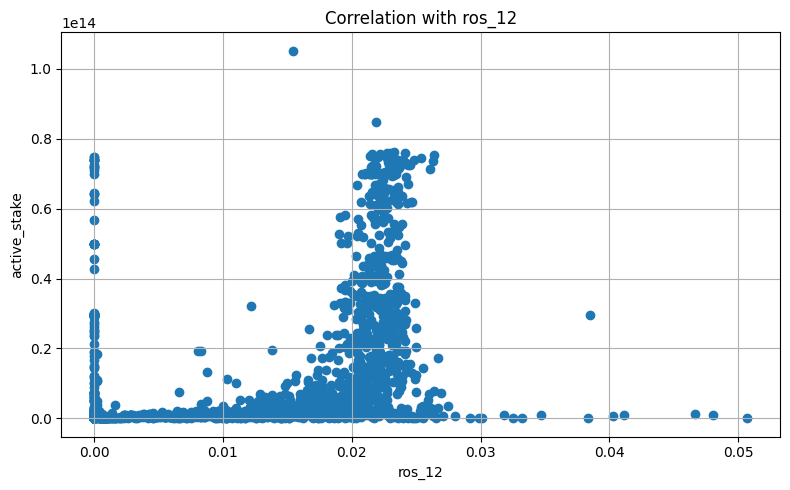

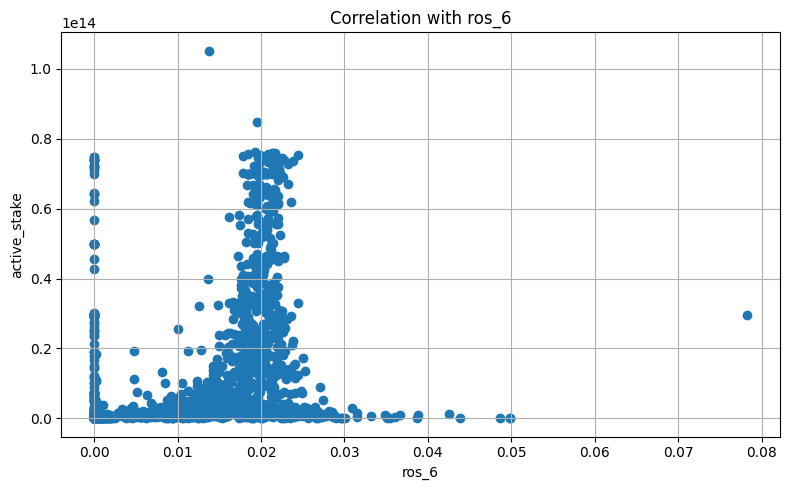

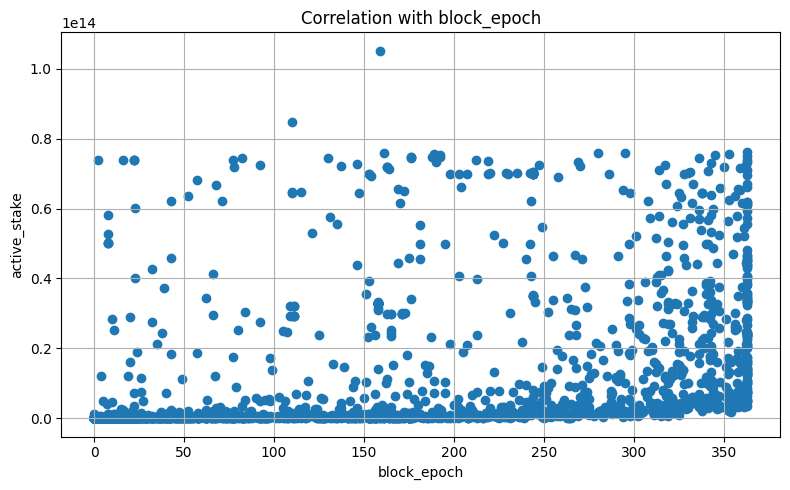

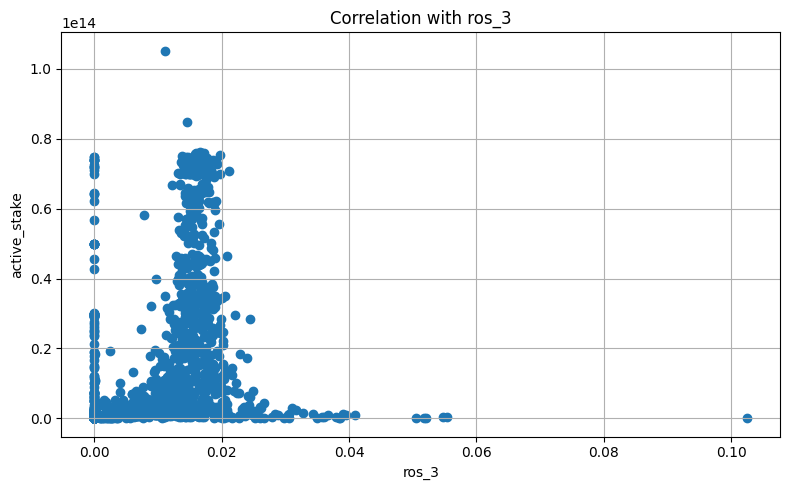

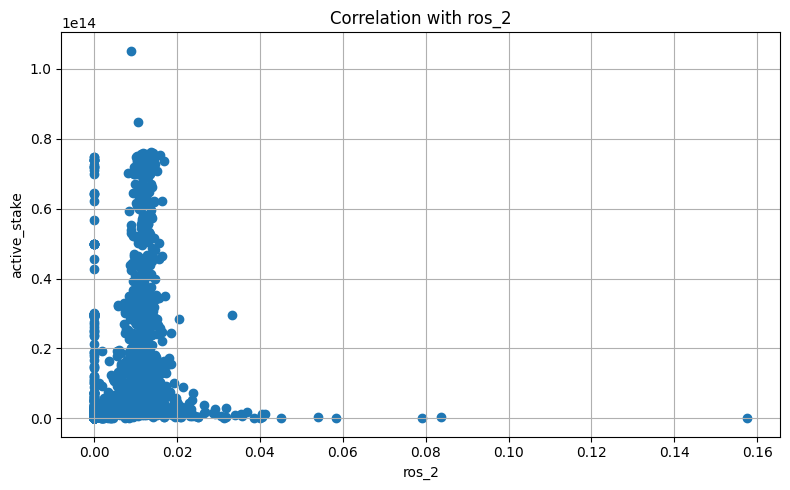

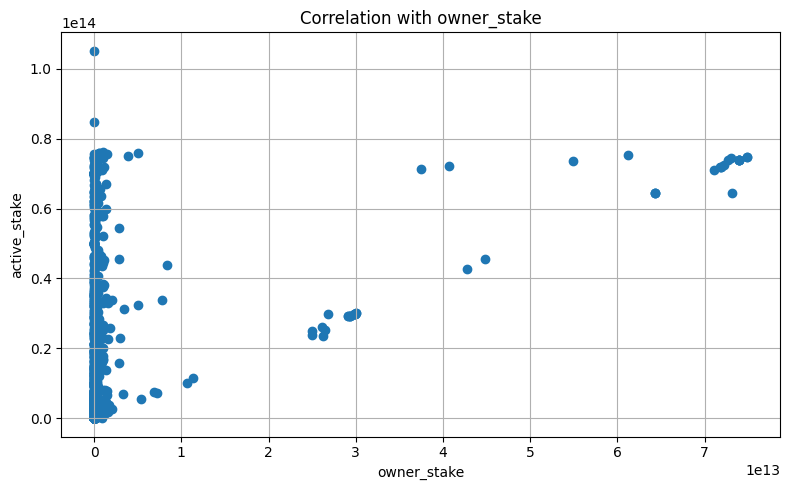

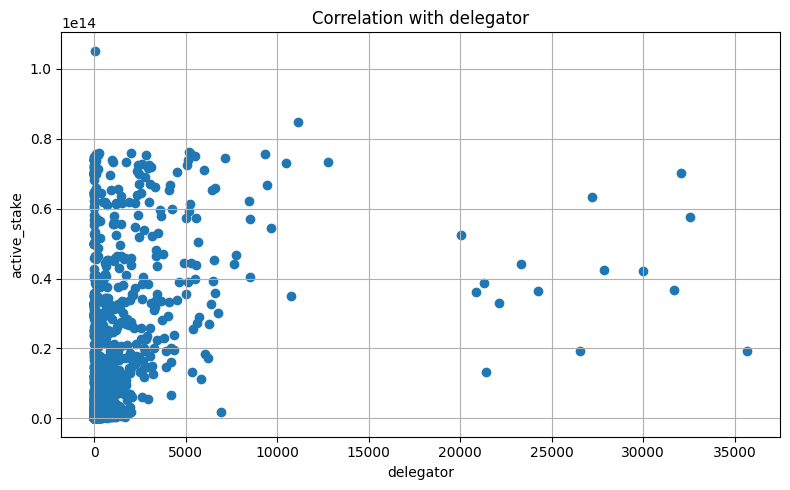

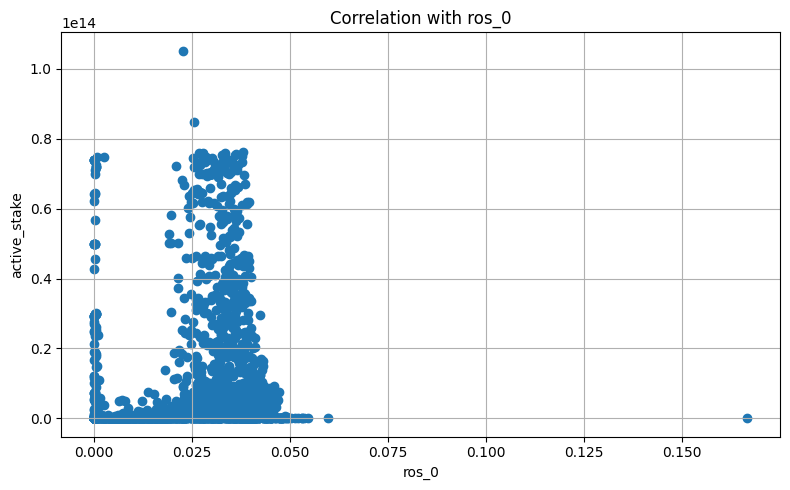

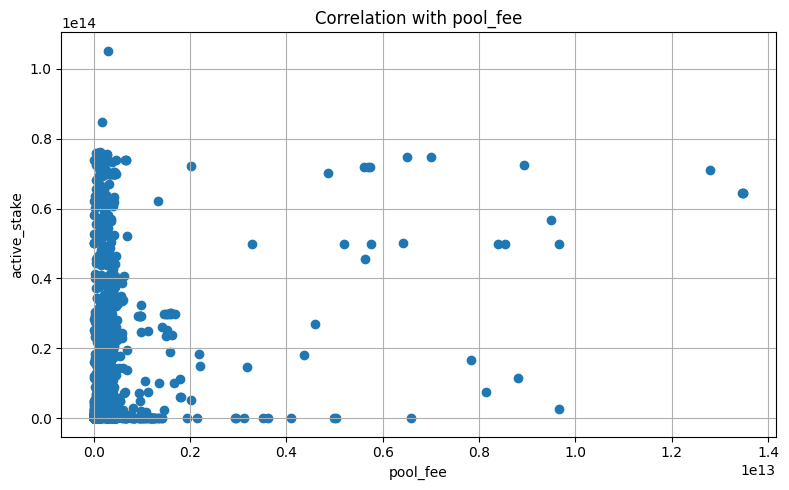

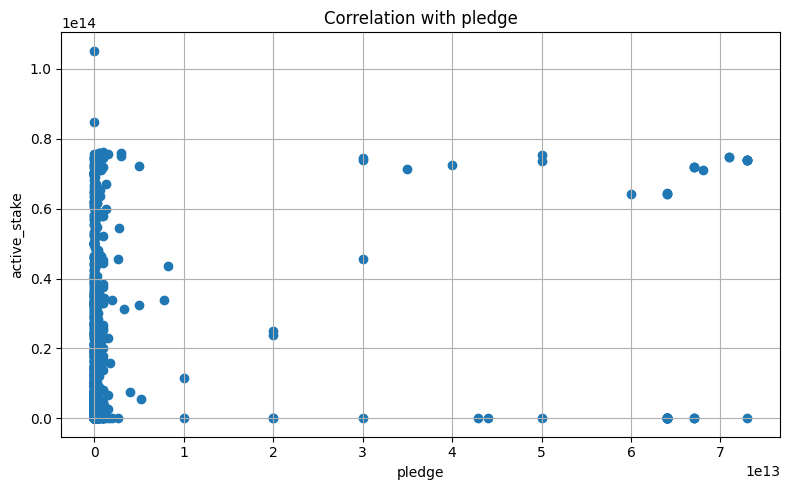

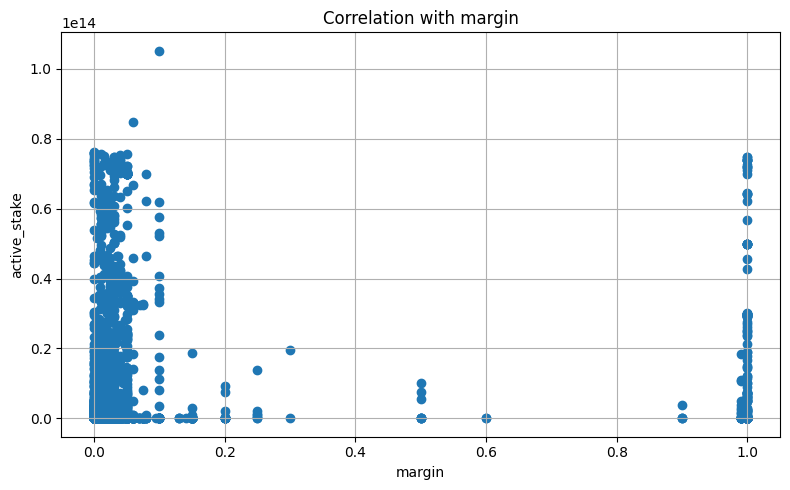

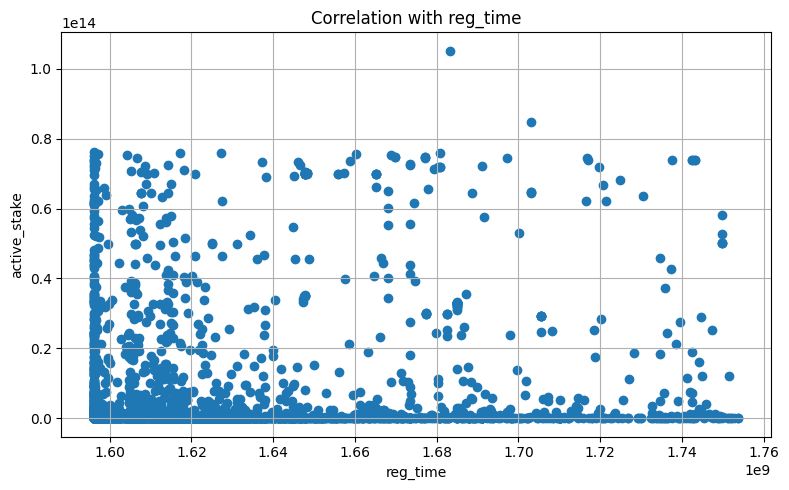

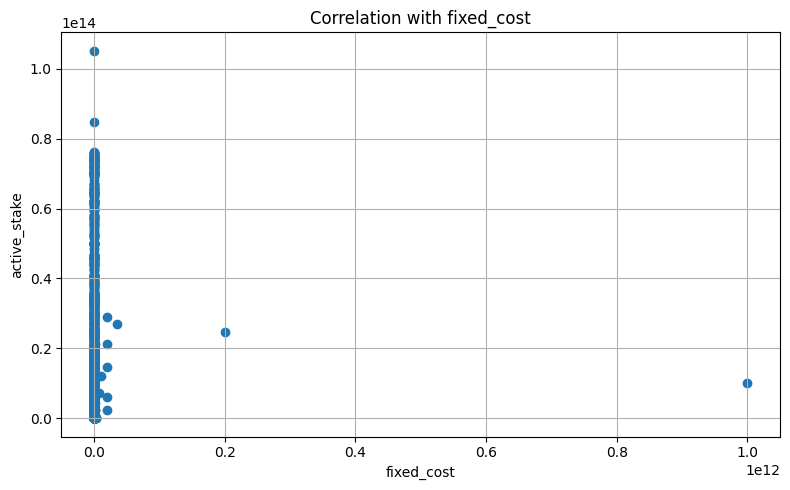

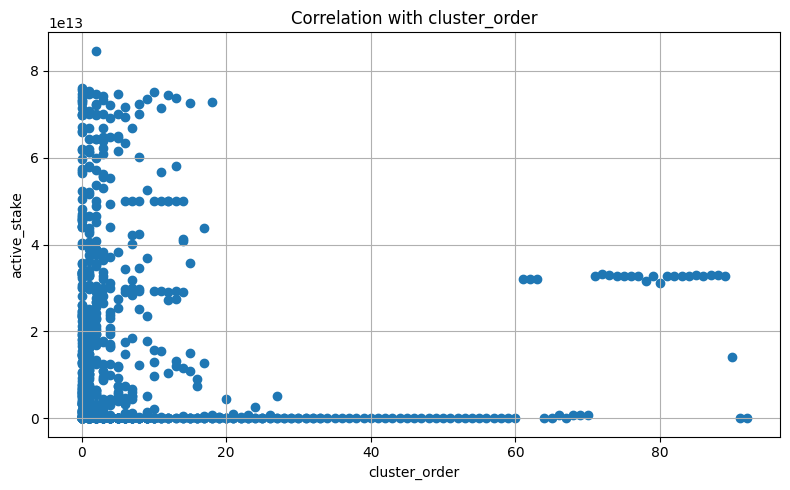

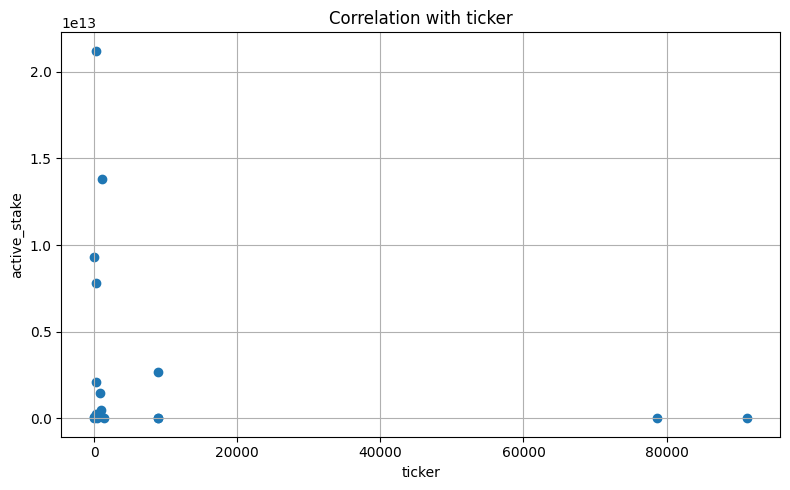

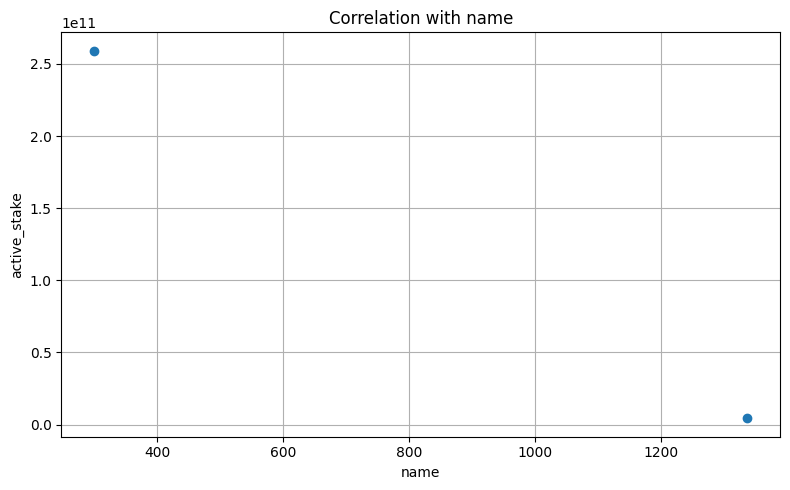

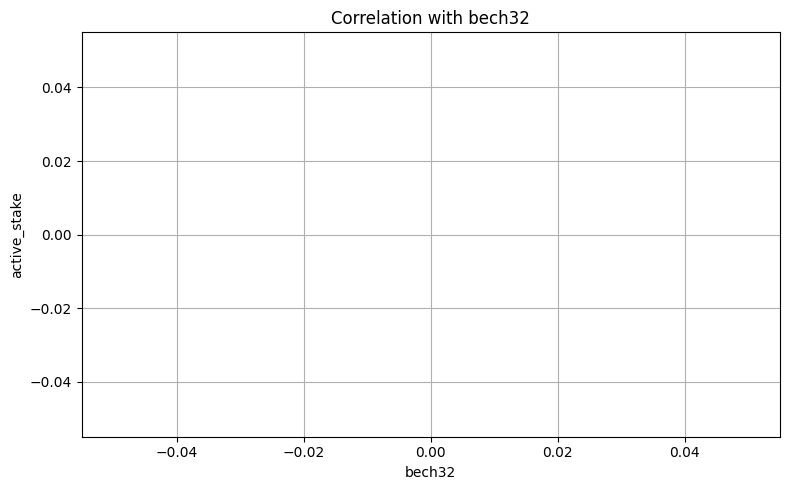

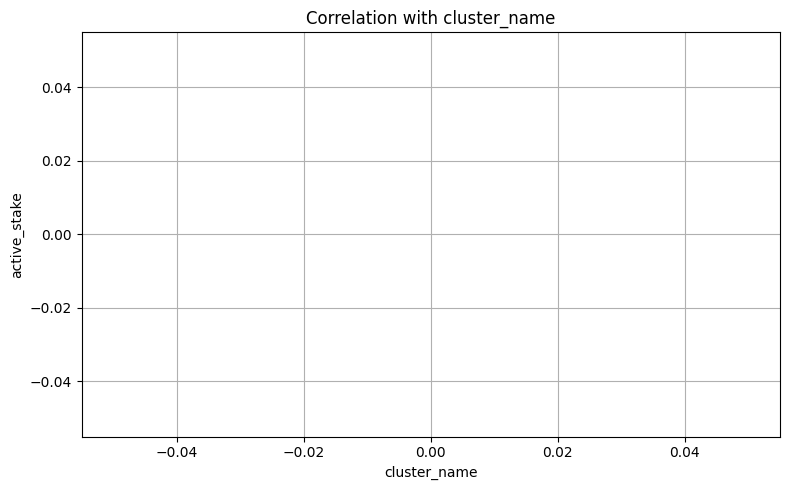

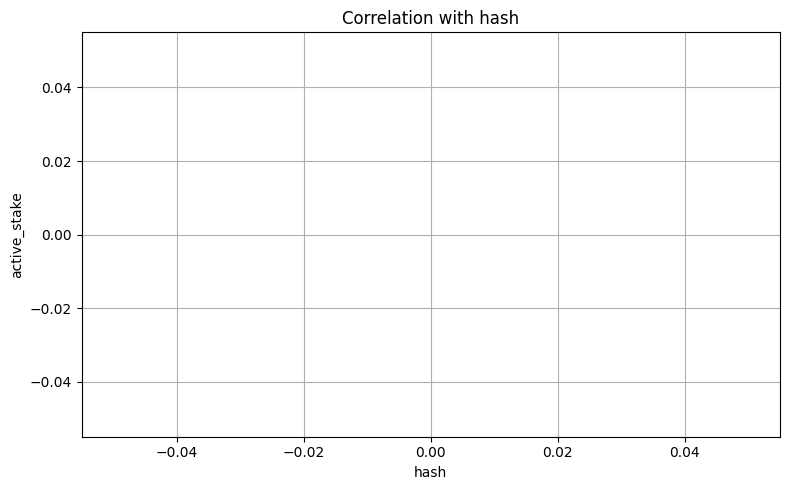

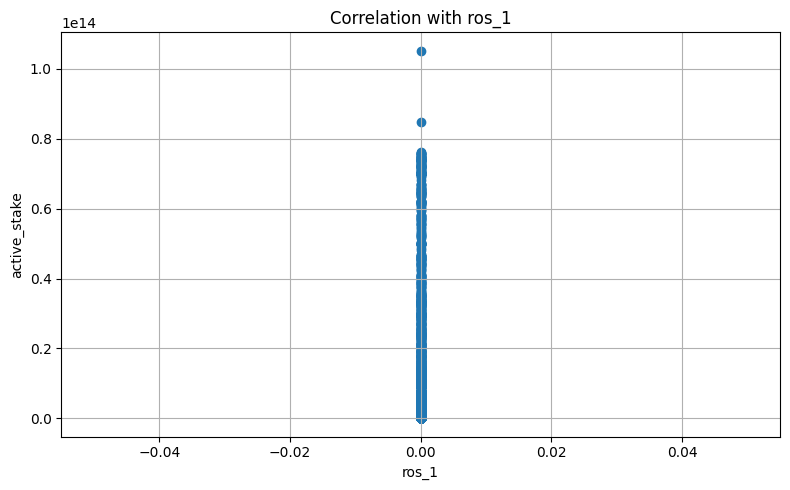

In [49]:

for corr in correlations.head(100).index:
    plot_two_axis(df_num, corr, 'active_stake', title=f'Correlation with {corr}', xlabel=corr, ylabel='active_stake')

In [57]:
# Convert the ticker column to string type
df["ticker"] = df["ticker"].astype(str)

# Then safely filter
df[df["ticker"].str.strip().str.upper() == "LIVIN"]

,active_stake,bech32,block,block_epoch,cluster_name,cluster_order,delegator,fixed_cost,hash,impersonator,...,ros_12,ros_18,ros_2,ros_3,ros_36,ros_6,ros_73,ticker,total_block,valid_meta


In [64]:
sum(df["total_block"])

6561542